In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /Users/sebastiangutierrezbernal/Desktop/Personal/Quantum Research/info-patterns-repo


In [2]:
from src.parameters import (SPHERE_GEOMETRY_PARAMS, DEFAULT_MATERIAL_NAME, DEFAULT_MATERIAL_KWARGS, DEFAULT_WAVELENGTH_NM, DEFAULT_FARFIELD_PARAMS, FAST_FARFIELD_PARAMS, 
                            DEFAULT_GAUSSIAN_FIELD_PARAMS, DEFAULT_DYADS_PARAMS, DEFAULT_COM_DISPLACEMENT_NM, DEFAULT_FORCE_DISPLACEMENTS_NM, DEFAULT_USETEX, DEFAULT_FONT_FAMILY, 
                            DEFAULT_FIGSIZE, DEFAULT_RESULTS_DIR, DEFAULT_SAVE_TYPE, DEFAULT_2D_PLANES, DEFAULT_2D_NORMALIZE, DEFAULT_2D_FILL)
from src.generate_nanoparticle import (nanoparticle_geometry, nanoparticle_material, nanoparticle_mass)
from src.light_matter_interaction_simulation import (incident_field, field_propagation, simulation_from_geometry, scattered_farfield_from_simulation)
from src.measurement_tools import (force_vs_displacement, recoil_force_noise_psd, trap_frequency, heating_rate)
from src.plots import (set_plot_style)
set_plot_style(usetex=DEFAULT_USETEX, font_family=DEFAULT_FONT_FAMILY, figsize=DEFAULT_FIGSIZE)
results_dir = "com_sphere_results"

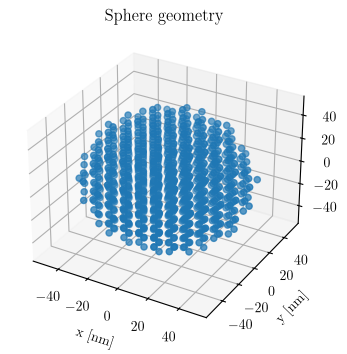

Geometry shape: (853, 3)
Geometry center: [ 0.0000000e+00  1.3706972e-06 -5.1813695e-05]
Material: <pyGDM2.materials.sio2 object at 0x1170976d0>
Mass: 1.326957e-18 kg


In [3]:
geometry = nanoparticle_geometry(**SPHERE_GEOMETRY_PARAMS)
material = nanoparticle_material(DEFAULT_MATERIAL_NAME, **DEFAULT_MATERIAL_KWARGS)
mass = nanoparticle_mass(geometry=geometry, particle_type=SPHERE_GEOMETRY_PARAMS["particle_type"], step_nm=SPHERE_GEOMETRY_PARAMS["step_nm"], material_name=DEFAULT_MATERIAL_NAME, 
                         mesh=SPHERE_GEOMETRY_PARAMS["mesh"], method="discrete")

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(geometry[:, 0], geometry[:, 1], geometry[:, 2], s=20)
ax.set_xlabel("x [nm]")
ax.set_ylabel("y [nm]")
ax.set_zlabel("z [nm]")
ax.set_title("Sphere geometry")
plt.show()

print("Geometry shape:", geometry.shape)
print("Geometry center:", np.mean(geometry, axis=0))
print("Material:", material)
print(f"Mass: {mass:.6e} kg")

In [4]:
farfield_params = DEFAULT_FARFIELD_PARAMS
Nteta = farfield_params["Nteta"]
Nphi = farfield_params["Nphi"]
field_index = farfield_params["field_index"]

efield = incident_field(**DEFAULT_GAUSSIAN_FIELD_PARAMS)
dyads = field_propagation(**DEFAULT_DYADS_PARAMS)

E_scat = scattered_farfield_from_simulation(geometry=geometry, step_nm=SPHERE_GEOMETRY_PARAMS["step_nm"], material=material, efield=efield, dyads=dyads, **farfield_params)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 4274.6ms, inv.: 251.7ms, repropa.: 242.8ms (1 field configs), tot: 4769.3ms


In [5]:
S_FF_x = recoil_force_noise_psd(Escat=E_scat[2], wavelength_nm=DEFAULT_WAVELENGTH_NM, Nteta=Nteta, Nphi=Nphi, mode_axis=0)
S_FF_y = recoil_force_noise_psd(Escat=E_scat[2], wavelength_nm=DEFAULT_WAVELENGTH_NM, Nteta=Nteta, Nphi=Nphi, mode_axis=1)
S_FF_z = recoil_force_noise_psd(Escat=E_scat[2], wavelength_nm=DEFAULT_WAVELENGTH_NM, Nteta=Nteta, Nphi=Nphi, mode_axis=2)

In [6]:
displacements = DEFAULT_FORCE_DISPLACEMENTS_NM
Force = force_vs_displacement(geometry=geometry, step_nm=SPHERE_GEOMETRY_PARAMS["step_nm"], material=material, efield=efield, dyads=dyads, displacements=displacements, field_index=field_index)

Omega_x, k_x = trap_frequency(displacements, Force["X"][:, 0], mass)
Omega_y, k_y = trap_frequency(displacements, Force["Y"][:, 1], mass)
Omega_z, k_z = trap_frequency(displacements, Force["Z"][:, 2], mass)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 52.3ms, inv.: 243.3ms, repropa.: 11.4ms (1 field configs), tot: 307.3ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 38.7ms, inv.: 223.7ms, repropa.: 7.0ms (1 field configs), tot: 269.5ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 40.7ms, inv.: 213.7ms, repropa.: 5.9ms (1 field configs), tot: 260.5ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 45.8ms, inv.: 216.8ms, repropa.: 6.0ms (1 field configs), tot: 268.8ms
structure initialization - automatic mesh detection: hex
structure init

In [7]:
Gamma_x = heating_rate(S_FF_x, mass, Omega_x) if not np.isnan(Omega_x) else np.nan
Gamma_y = heating_rate(S_FF_y, mass, Omega_y) if not np.isnan(Omega_y) else np.nan
Gamma_z = heating_rate(S_FF_z, mass, Omega_z) if not np.isnan(Omega_z) else np.nan

In [8]:
print("Mass")
print(f"m = {mass:.6e} kg")

print("\nTrap stiffness")
print(f"k_x = {k_x:.6e} N/m")
print(f"k_y = {k_y:.6e} N/m")
print(f"k_z = {k_z:.6e} N/m")

print("\nTrap frequencies")
print(f"Omega_x = {Omega_x:.6e} rad/s, f_x = {Omega_x / (2*np.pi):.6e} Hz")
print(f"Omega_y = {Omega_y:.6e} rad/s, f_y = {Omega_y / (2*np.pi):.6e} Hz")
print(f"Omega_z = {Omega_z:.6e} rad/s, f_z = {Omega_z / (2*np.pi):.6e} Hz")

print("\nRecoil force-noise PSD")
print(f"S_FF_x = {S_FF_x:.6e}")
print(f"S_FF_y = {S_FF_y:.6e}")
print(f"S_FF_z = {S_FF_z:.6e}")

print("\nRecoil heating rates")
print(f"Gamma_x = {Gamma_x:.6e} phonons/s")
print(f"Gamma_y = {Gamma_y:.6e} phonons/s")
print(f"Gamma_z = {Gamma_z:.6e} phonons/s")

Mass
m = 1.326957e-18 kg

Trap stiffness
k_x = 2.451183e-23 N/m
k_y = 1.768792e-24 N/m
k_z = -4.273157e-26 N/m

Trap frequencies
Omega_x = 4.297932e-03 rad/s, f_x = 6.840371e-04 Hz
Omega_y = 1.154543e-03 rad/s, f_y = 1.837512e-04 Hz
Omega_z = nan rad/s, f_z = nan Hz

Recoil force-noise PSD
S_FF_x = 1.137117e-32
S_FF_y = 2.262103e-32
S_FF_z = 2.265275e-32

Recoil heating rates
Gamma_x = 5.939673e+22 phonons/s
Gamma_y = 4.398650e+23 phonons/s
Gamma_z = nan phonons/s
